<div style="border: 3px solid #1f6fb2; border-radius: 10px; padding: 52px 44px; text-align: center; background: linear-gradient(160deg, #f8fbff 0%, #e4f0fc 100%); margin-bottom: 8px;">
  <div style="font-size: 56px; font-weight: 900; color: #1f6fb2; letter-spacing: 4px; margin-bottom: 18px; font-family: sans-serif;">
    ICU SEPSIS RL
  </div>
  <div style="font-size: 20px; font-weight: 700; color: #1a3a5c; margin-bottom: 8px;">
    Clinical Treatment Optimisation: Sepsis ICU Management
  </div>
  <div style="font-size: 15px; font-style: italic; color: #4a6a8a; margin-bottom: 38px;">
    Configuration B – Deep Reinforcement Learning
  </div>
  <hr style="border: none; border-top: 2px solid #1f6fb2; width: 48%; margin: 0 auto 28px auto;">
  <div style="font-size: 14px; font-weight: 600; color: #1a3a5c; margin-bottom: 6px;">
    Ana Gonçalves &nbsp;|&nbsp; Catarina &nbsp;|&nbsp; Filipa São João &nbsp;|&nbsp; Inês Esteves &nbsp;|&nbsp; Maria
  </div>
  <div style="font-size: 13px; font-style: italic; color: #6a8aaa;">
    NOVA IMS – Master in Data Science &amp; Advanced Analytics - Reinforcement Learning - May 2026
  </div>
</div>


<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Notebook Overview](#1)
- [2. Set Up & Import Libraries](#2)

  


# <font color='#2f94d7' size=6>**1. Notebook Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

!! EXPLICAR O QUE É ESTE NOTEBOOK E O QUE TEMS AQUI

# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [1]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys
import gymnasium as gym
import random
import time
import itertools

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
from collections import deque
import optuna
from optuna.samplers import TPESampler
from optuna.pruners  import MedianPruner

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

warnings.filterwarnings('ignore')

# Project modules
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)
from envs.continuous_sepsis_env import ContinuousICUSepsisEnv, FEATURE_NAMES
from envs.wrappers import (
    EpisodicNoisyObsEnv, EpisodicMissingObsEnv,
    AcuteEventEnv, make_clinical_env
)

# Import everything from algorithms and utils
from src.dqn_sac_functions import *
from src.utils import *
from src.ppo_functions import *
from src.creative_extension import *


# Config B constants
OBS_DIM = 47

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')

Device: cpu


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [2]:
# Config B observation constants
OBS_DIM  = 47   # 47 physiological features

In [3]:
# Verify wrapper stack order
test_env = make_clinical_env()
e = test_env
layers = []
while hasattr(e, 'env'):
    layers.append(type(e).__name__)
    e = e.env
layers.append(type(e).__name__)
test_env.close()


print()
print('Clinical environment wrapper stack (outer → inner):')
for i, layer in enumerate(layers):
    prefix = '  ' * i + ('└─ ' if i > 0 else '┌─ ')
    print(f'{prefix}{layer}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Clinical environment wrapper stack (outer → inner):
┌─ AcuteEventEnv
  └─ EpisodicMissingObsEnv
    └─ EpisodicNoisyObsEnv
      └─ ContinuousICUSepsisEnv


In [4]:
# REPRODUCIBILITY
SEED      = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

In [5]:
# Random baseline — clinical environment
N_EPISODES_BASELINE = 1_000
clinical_env_base = make_clinical_env()
records_baseline  = rollout(clinical_env_base, N_EPISODES_BASELINE)
clinical_env_base.close()

clinical_rand_mean = float(np.mean([r['return'] for r in records_baseline]))
print(f'Random baseline mean return : {clinical_rand_mean:.4f}')
print(f'Random baseline survival    : {np.mean([r["survived"] for r in records_baseline])*100:.1f}%')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random baseline mean return : 0.5632
Random baseline survival    : 65.5%


# <font color='#2f94d7' size=6>**3. Discrete SAC (Discrete Soft Actor-Critic)**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**3.1 SAC — Rationale & Architecture**</font> <a class="anchor" id="3_1"></a>

[Back to TOC](#toc)

**Why SAC?**

While DQN learns a deterministic greedy policy, it can overestimate Q-values and struggles with stochastic environments. SAC (Soft Actor-Critic) addresses both issues by adding an **entropy bonus** to the reward signal, explicitly encouraging the agent to remain uncertain about its actions when uncertainty is warranted. In the clinical setting, this translates to a more cautious policy: rather than committing to a single treatment aggressively, the agent maintains a distribution over actions and only collapses to near-deterministic behaviour when the evidence is strong.

SAC also uses **double-Q critics** — two independent critic networks — to reduce overestimation bias. The target is computed as the minimum of both, a conservative estimate that prevents the inflated Q-values that destabilise DQN in sparse-reward environments like sepsis management.

The key innovations that make SAC effective here are:

1. **Entropy-regularised objective**: the agent maximises expected return *plus* a weighted policy entropy term, controlled by the temperature parameter α. This prevents premature convergence to suboptimal deterministic policies.
2. **Double-Q critics with soft target updates**: instead of hard copying the target network every N episodes (as in DQN), SAC uses Polyak averaging (τ = 0.005), producing smoother and more stable learning targets throughout training.
3. **Off-policy learning with replay buffer**: like DQN, SAC stores transitions in a replay buffer and samples random mini-batches, breaking temporal correlations — but the actor update uses the *current* policy's distribution over all actions rather than the argmax, making it compatible with the full action space.

**Maximum entropy Bellman target:**

$$Q(s, a) \leftarrow r + \gamma \, \mathbb{E}_{a' \sim \pi}\bigl[\min(Q_{\theta_1^-}, Q_{\theta_2^-})(s', a') - \alpha \log \pi(a' \mid s')\bigr]$$

where $\theta_1^-, \theta_2^-$ are the two target critic parameters and $\alpha$ controls the exploration–exploitation trade-off.

**Architecture choice:**
- Input layer: 47 features
- Two hidden layers: 256 units each, with ReLU activations
- **Actor head**: outputs logits → softmax probabilities over 25 actions
- **Two critic heads** (double-Q): each outputs 25 Q-values simultaneously
- Actor loss: minimises $\alpha \log \pi(a|s) - Q(s,a)$ in expectation over the current policy
- Critic loss: MSE against the entropy-regularised Bellman target

**Training configuration:** 15,000 episodes, replay buffer of 100,000 transitions, batch size 256, learning rates $3 \times 10^{-4}$ for both actor and critics, $\alpha = 0.05$, $\tau = 0.005$.

## <font color='#2f94d7' size=6_1>**3.2 Discrete SAC - Training (Run 1)**</font> <a class="anchor" id="3_2"></a>

[Back to TOC](#toc)

Before committing to expensive hyperparameter searches, we ran an initial training pass
with a fixed set of baseline parameters to establish a performance reference and verify
that the implementation was stable. This informs the subsequent Optuna optimisation,
knowing roughly what range of returns to expect makes it easier to detect pruning
candidates early and set meaningful search bounds.

In [6]:
# Quick architecture summary
actor_test   = SACActor(OBS_DIM, N_ACTIONS)
critic_test  = SACCritic(OBS_DIM, N_ACTIONS)
n_params_actor  = sum(p.numel() for p in actor_test.parameters())
n_params_critic = sum(p.numel() for p in critic_test.parameters())
n_params_total  = n_params_actor + 2 * n_params_critic  # two critics

print('SACActor architecture:')
print(actor_test)
print(f'\nSACCritic architecture:')
print(critic_test)
print(f'\nActor parameters  : {n_params_actor:,}')
print(f'Critic parameters : {n_params_critic:,}  × 2 critics')
print(f'Total parameters  : {n_params_total:,}')
test_obs  = torch.zeros(1, OBS_DIM)
probs, lp = actor_test(test_obs)
print(f'\nActor output shape (batch=1): {probs.shape}  → one probability per action')
q_out = critic_test(test_obs)
print(f'Critic output shape (batch=1): {q_out.shape}  → one Q-value per action')

SACActor architecture:
SACActor(
  (net): Sequential(
    (0): Linear(in_features=47, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=25, bias=True)
  )
)

SACCritic architecture:
SACCritic(
  (net): Sequential(
    (0): Linear(in_features=47, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=25, bias=True)
  )
)

Actor parameters  : 84,505
Critic parameters : 84,505  × 2 critics
Total parameters  : 253,515

Actor output shape (batch=1): torch.Size([1, 25])  → one probability per action
Critic output shape (batch=1): torch.Size([1, 25])  → one Q-value per action


In [7]:
# SAC — Hyperparameters Run 1
SAC_EPISODES   = 15_000   # total training episodes
SAC_BUFFER     = 100_000  # replay buffer size
SAC_BATCH      = 256      # mini-batch size
SAC_LR_ACTOR   = 3e-4     # actor learning rate
SAC_LR_CRITIC  = 3e-4     # critic learning rate
SAC_ALPHA      = 0.05     # entropy temperature
SAC_TAU        = 0.005    # Polyak averaging rate
SAC_MIN_BUFFER = 1_000    # start training after N transitions
SAC_HIDDEN     = 256      # hidden layer size

In [ ]:
# Train SAC - Run 1
sac_r1 = train_sac(
    run_id      = 1,
    n_episodes  = SAC_EPISODES,
    buffer_size = SAC_BUFFER,
    batch_size  = SAC_BATCH,
    min_buffer  = SAC_MIN_BUFFER,
    lr_actor    = SAC_LR_ACTOR,
    lr_critic   = SAC_LR_CRITIC,
    alpha       = SAC_ALPHA,
    tau         = SAC_TAU,
    hidden      = SAC_HIDDEN,
    verbose     = 500,
    save_dir    = 'models/sac',
)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[SAC Run v2_doubleQ] Ep   500/15000 | return: 0.5108 | Q_mean: +1.592 | entropy: 1.222 | c_loss: 0.0539
[SAC Run v2_doubleQ] Ep  1000/15000 | return: 0.5592 | Q_mean: +2.238 | entropy: 0.548 | c_loss: 0.2341
[SAC Run v2_doubleQ] Ep  1500/15000 | return: 0.5654 | Q_mean: +2.032 | entropy: 0.484 | c_loss: 0.2526
[SAC Run v2_doubleQ] Ep  2000/15000 | return: 0.5756 | Q_mean: +1.714 | entropy: 0.575 | c_loss: 0.1990
[SAC Run v2_doubleQ] Ep  2500/15000 | return: 0.5321 | Q_mean: +1.437 | entropy: 0.745 | c_loss: 0.1353
[SAC Run v2_doubleQ] Ep  3000/15000 | return: 0.5833 | Q_mean: +1.324 | entropy: 0.854 | c_loss: 0.1187
[SAC Run v2_doubleQ] Ep  3500/15000 | return: 0.5499 | Q_mean: +1.245 | entropy: 0.969 | c_loss: 0.1026
[SAC Run v2_doubleQ] Ep  4000/15000 | return: 0.5612 | Q_mean: +1.205 | entropy: 1.046 | c_loss: 0.0970
[SAC Run v2_doubleQ] Ep  4500/15000 | return: 0.5464 | Q_m

In [8]:
# Load the best SAC actor from the saved file
sac_actor = SACActor(OBS_DIM, N_ACTIONS).to(device)
sac_actor.load_state_dict(torch.load('models/sac/sac_actor_runv2_doubleQ.pth', map_location=device))
sac_actor.eval()

# Evaluate SAC on the clinical environment (with wrappers) - Run 1
sac_eval = evaluate(sac_actor, make_clinical_env, is_sac=True,
                    label='SAC Run 1', baseline=clinical_rand_mean)

SAC_SURVIVAL = float(np.mean(sac_eval['returns'] > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  SAC Run 1 — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 64.5%
  Mean return            : 0.5608
  Mean episode length    : 9.2 steps
  vs Random baseline     : +8.2pp
────────────────────────────────────────────────────
  Noisy episodes   (138): 63.8% survival
  Clean episodes   (862): 64.6% survival
  Missing feat. ep (130): 58.5% survival
  Acute event ep   ( 91): 0.0% survival
  No acute event   (909): 71.0% survival
════════════════════════════════════════════════════


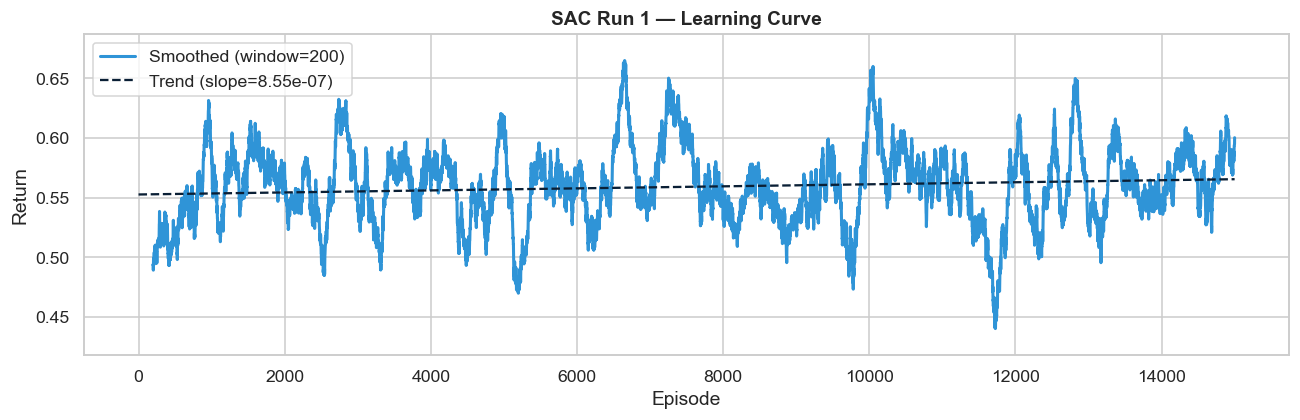

In [9]:
# SAC Run 1 - Learning Curve
sac_all_returns = np.load('models/sac/sac_returns_runv2_doubleQ.npy')

plot_learning_curve(sac_all_returns, label='SAC Run 1', window=200)

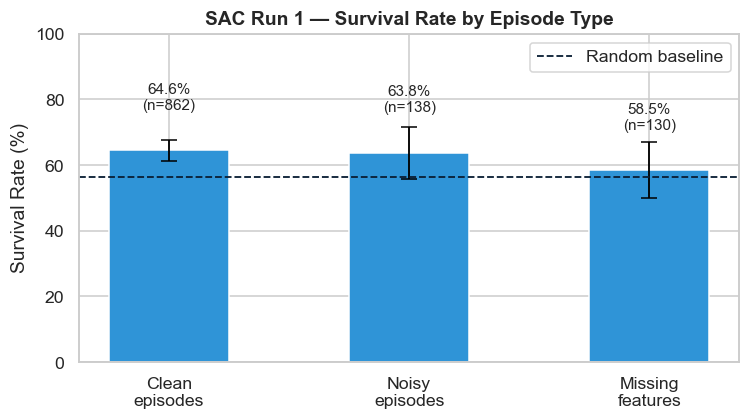

In [10]:
# SAC Run 1 - Episode type comparison
plot_episode_type_comparison(sac_eval['noisy'], sac_eval['clean'], sac_eval['missing'],
                             label='SAC Run 1', baseline=clinical_rand_mean)

**Results — SAC Run 1**

The baseline run achieved a survival rate of **64.5%** (mean return: 0.5608),
representing a **+8.2 pp improvement over the random baseline** (~56.3%).
Training ran for 15,000 episodes, with a mean episode length of 9.2 steps.

The learning curve shows **high variance throughout**, which is expected given
the stochastic clinical wrappers and sparse reward signal. Despite the noise,
the trend line (slope = 8.55e-07) confirms a **slow but consistent upward
progression**, the policy does improve over time, though convergence is not
yet reached at 15,000 episodes.

**Performance by episode type:**

| Episode type     | n   | Survival rate |
|------------------|-----|---------------|
| Clean episodes   | 862 | 64.6%         |
| Noisy episodes   | 138 | 63.8%         |
| Missing features | 130 | 58.5%         |

Performance is broadly consistent across clean and noisy episodes (64.6% vs
63.8%), suggesting the entropy-regularised policy is naturally robust to
observation noise, the maintained action distribution absorbs small
perturbations without committing to a wrong action. However, missing features
episodes show a more notable drop to **58.5%**, close to the random baseline,
indicating the agent struggles when entire lab measurements are unavailable.

Notably, acute events resulted in **0.0% survival** (91 episodes), which is
expected, these are irreducible stochastic deaths independent of any
treatment decision, not a failure of the policy itself.

These results establish the reference point for the Optuna optimisation in Section 6.3.